In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path=(r'C:\Users\vijay\Documents\NareshIT\data_files\Visadataset.csv')

In [3]:
visa_df=pd.read_csv(file_path)

In [4]:
type(visa_df)

pandas.core.frame.DataFrame

In [5]:
cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [6]:
type(num),type(cat)

(pandas.core.indexes.base.Index, pandas.core.indexes.base.Index)

**prevailing wage column**

In [7]:
pwage=visa_df['prevailing_wage']

In [8]:
min(pwage) #basic python

2.1367

In [9]:
np.min(pwage) #numpy

2.1367

In [10]:
pwage.min() #pandas

2.1367

In [11]:
np.max(pwage)

319210.27

In [12]:
np.mean(pwage)

np.float64(74455.81459209183)

In [13]:
np.median(pwage)

np.float64(70308.20999999999)

In [14]:
len(pwage)

25480

**pecentile-quantile**

In [15]:
#25 percentile
np.percentile(pwage,25)

np.float64(34015.479999999996)

In [16]:
np.quantile(pwage,0.25)

np.float64(34015.479999999996)

In [17]:
np.percentile(pwage,50)

np.float64(70308.20999999999)

In [18]:
np.quantile(pwage,0.50)

np.float64(70308.20999999999)

In [19]:
np.percentile(pwage,75)

np.float64(107735.51250000001)

In [20]:
np.quantile(pwage,0.75)

np.float64(107735.51250000001)

In [21]:
#pwage=df[i]
pcount=pwage.count()
pmin=np.min(pwage)
p25=np.percentile(pwage,25)
pmean=np.mean(pwage)
pmedian=np.median(pwage)
p50=np.percentile(pwage,50)
p75=np.percentile(pwage,75)
pmax=np.max(pwage)

In [22]:
metrics=[pcount,pmin,p25,pmean,pmedian,p50,p75,pmax]
ID=['count','min','25%','pmean','pmedian','50%','75%','pmax']        

In [23]:
l=[]
for i in num: 
    pwage=visa_df[i]
    pcount=pwage.count()
    pmin=np.min(pwage)
    p25=np.percentile(pwage,25)
    pmean=np.mean(pwage)
    pmedian=np.median(pwage)
    p50=np.percentile(pwage,50)
    p75=np.percentile(pwage,75)
    pmax=np.max(pwage)
    metrics=[pcount,pmin,p25,pmean,pmedian,p50,p75,pmax]
    #ID=['count','min','p25','pmean','pmedian','p50','p75','pmax']   
    l.append(metrics)
    

In [24]:
pd.DataFrame(l,num,columns=ID)

,count,min,25%,pmean,pmedian,50%,75%,pmax
no_of_employees,25480,-26.0000,1022.00,5667.043210,2109.00,2109.00,3504.0000,602069.00
yr_of_estab,25480,1800.0000,1976.00,1979.409929,1997.00,1997.00,2005.0000,2016.00
prevailing_wage,25480,2.1367,34015.48,74455.814592,70308.21,70308.21,107735.5125,319210.27


In [25]:
visa_df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**precentile**

- 25p=34015

- there is 25% of data has value less than 34015

- what is total data

- 25480

- 25% of 25480

- 25480*25/100=6037

- this means 6370 people has value less than 34015 

In [26]:
# step-1 total data :visa_df=['prevailing_wage']
# step-2 25

In [27]:
pwage=visa_df['prevailing_wage'] 
p_25=np.percentile(pwage,25)
con=pwage <p_25
len(visa_df[con])

6370

In [28]:
p_50=np.percentile(pwage,50)
con1=pwage <p_50
len(visa_df[con1])


12740

In [29]:
p_75=np.percentile(pwage,75)
con2=pwage <p_75
len(visa_df[con2])

19110

In [30]:
p_100=np.percentile(pwage,100)
con3=pwage <p_100
len(visa_df[con3])

25479

**emperical rule**

In [31]:
# u-1*sigma u+1*sigma
wage_mean=np.mean(pwage)
wage_std=np.std(pwage)
lb=wage_mean-1*wage_std
up=wage_mean+1*wage_std

In [32]:
lb,up

(np.float64(21640.908694977814), np.float64(127270.72048920585))

In [33]:
wage_data=visa_df['prevailing_wage']
cond1=wage_data>lb
cond2=wage_data<up

In [34]:
cond=cond1&cond2

In [35]:
len(visa_df[cond])==25480*68/100

False

In [36]:
wage_mean=np.mean(pwage)
wage_std=np.std(pwage)
lb=wage_mean-1*wage_std
up1=wage_mean+2*wage_std
wage_data=visa_df['prevailing_wage']
cond1=wage_data>lb
cond3=wage_data<up1
condd=cond1&cond3
len(visa_df[cond])==25480*95/100

False

In [37]:
wage_mean=np.mean(pwage)
wage_std=np.std(pwage)
lb=wage_mean-1*wage_std
up1=wage_mean+3*wage_std
wage_data=visa_df['prevailing_wage']
cond1=wage_data>lb
cond4=wage_data<up1
cond=cond1&cond4
len(visa_df[cond])==25480*99.7/100

False

**emperical rule valid for normal distribution**

- the above analysis conclude data does not follow normal distribution

**histogram**

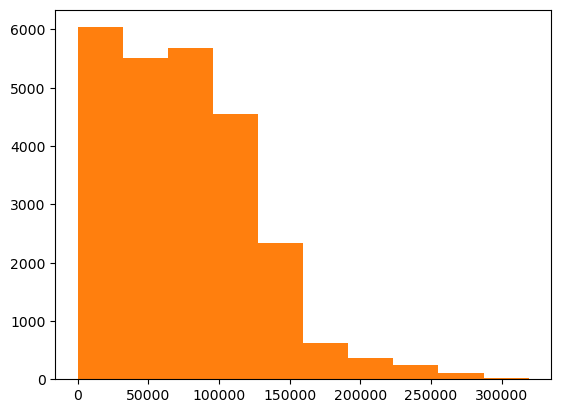

In [38]:
plt.hist(wage_data)
#plt.show()
f,value,n=plt.hist(wage_data)

In [39]:
n

<BarContainer object of 10 artists>

In [40]:
value

array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
       1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
       2.55368643e+05, 2.87289457e+05, 3.19210270e+05])

In [41]:
f

array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
         21.])

In [42]:
#there are 6038 applicant has wages between 2.1367 to 31922.97


In [43]:
#04/12/2025

# for one interval we need two values
# for 10 intervals we need 11 values
- fuction return 3 outputs
- count for each interval
- interval values
- number of intervals
- 

In [44]:
wage_data=visa_df['prevailing_wage']


In [45]:
lb=2.13670000e+00
up=3.19229500e+04
con1=wage_data >=lb
con2=wage_data <=up
con3=con1 & con2
len(visa_df[con3])

6038

In [46]:
up

31922.95

In [47]:
up

31922.95

In [48]:
# #assignment
# lb     up      count
# 2.137 31922.95  6038 

# do it for all the intervals


In [50]:
- we define percentile

- we explore about emperical rule

- emperical rule failed

- that means data does not follow normal distribution

- we also check with histogram

- histogram also supported our research data has no noraml distribution

- it has right skew so that some outliers present

- we need to visualize that by bot plot

              Q1-1.5IQR   Q1   median  Q3   Q3+1.5IQR
                       |-----:-----|
       o      |--------|     :     |--------|    o  o
                       |-----:-----|
     flier             <----------->            fliers
                            IQR


IndentationError: unindent does not match any outer indentation level (<string>, line 19)

{'whiskers': [<matplotlib.lines.Line2D at 0x1c0eb3d1a90>,
 'caps': [<matplotlib.lines.Line2D at 0x1c0eb3d1d10>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c0eb3d1950>],
 'medians': [<matplotlib.lines.Line2D at 0x1c0eb3d1f90>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c0eb3d20d0>],
 'means': []}

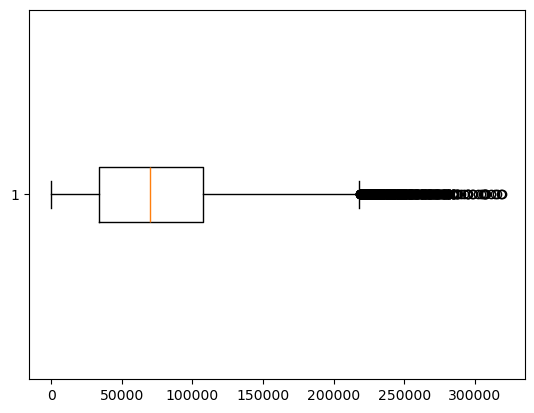

In [51]:
plt.boxplot(wage_data,vert=False)

In [52]:
- step 1 calculate :q1
- step 2 calculate :q2
- step 2 calculate :q3
- step 4 calculate :iqr=q3-q1
- step 5 calculate :lb=q1-1.5*iqr
- step 6 calculate :up=q3_1.5*iqr
- step 7 con1
- step 8 con2
- step 9 cond=con1 or con2
- step 10 get the count

SyntaxError: invalid syntax (4248823846.py, line 1)

In [53]:
pwage=visa_df['prevailing_wage'] 
p_25=np.percentile(pwage,25)
con=pwage <p_25
len(visa_df[con])

6370

In [54]:
pwage=visa_df['prevailing_wage'] 
p_50=np.percentile(pwage,50)
con=pwage <p_50
len(visa_df[con])

12740

In [55]:
pwage=visa_df['prevailing_wage'] 
p_75=np.percentile(pwage,75)
con=pwage <p_75
len(visa_df[con])

19110

In [56]:
iqr=p75-p_25

In [57]:
lb=p_25-(1.5*iqr)

In [58]:
up=p_75+(1.5*iqr)

In [59]:
con1 = wage_data <lb

In [60]:
con2 = wage_data >up

In [61]:
con3 = con1 | con2

In [62]:
len(visa_df[con3])

427

In [63]:
outlier_df=visa_df[con3]

In [64]:
outlier_df['prevailing_wage']

14       220081.73
34       225569.73
130      247393.01
216      269321.68
221      219529.62
           ...    
25191    280482.51
25195    234308.77
25468    272715.74
25469    273772.47
25476    279174.79
Name: prevailing_wage, Length: 427, dtype: float64

In [65]:
outlier_df['prevailing_wage'].values

array([220081.73, 225569.73, 247393.01, 269321.68, 219529.62, 232227.33,
       238691.32, 220448.17, 230750.48, 235339.91, 232680.65, 256261.78,
       262189.  , 250510.67, 218554.78, 256205.38, 221944.22, 229950.7 ,
       222628.84, 229819.69, 233641.72, 274019.43, 218982.83, 230984.28,
       223128.23, 246705.  , 240266.34, 226090.72, 231949.27, 254604.08,
       288318.91, 244457.48, 242146.48, 247545.23, 234139.17, 231834.72,
       222730.57, 239773.63, 220553.95, 237539.32, 266440.49, 277281.01,
       275627.59, 249291.12, 292106.59, 234012.11, 247009.24, 267726.09,
       222098.09, 280661.13, 277984.52, 262852.71, 263877.21, 230916.64,
       264760.64, 267868.56, 222221.67, 242406.32, 276894.08, 281832.93,
       221033.57, 258292.84, 223492.85, 245418.67, 250289.08, 271344.69,
       252825.11, 230843.7 , 253668.86, 245819.17, 239465.3 , 236316.36,
       225268.13, 228941.33, 306021.96, 228074.25, 270799.93, 221982.69,
       256903.7 , 242813.07, 253111.05, 268440.33, 

In [66]:
outlier_list=outlier_df['prevailing_wage'].values.tolist()

In [67]:
wage_median=visa_df['prevailing_wage'].median()

In [68]:
wage_data=visa_df['prevailing_wage']

In [69]:
new_wage_data=[]

In [85]:
for i in wage_data :
    if i in outlier_list:
        new_wage_data.append(wage_median)
    else:
        new_wage_data.append(i)
        

(array([6038., 5504., 5681., 4551., 2334.,  624.,  373.,  240.,  114.,
          21.]),
 array([2.13670000e+00, 3.19229500e+04, 6.38437634e+04, 9.57645767e+04,
        1.27685390e+05, 1.59606203e+05, 1.91527017e+05, 2.23447830e+05,
        2.55368643e+05, 2.87289457e+05, 3.19210270e+05]),
 <BarContainer object of 10 artists>)

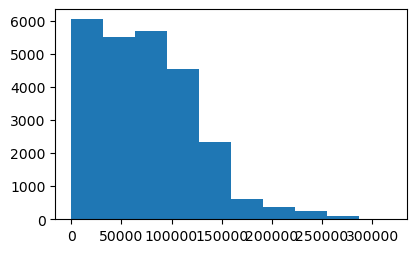

In [86]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.hist(wage_data)

(array([9160., 6736., 7780., 8738., 7014., 5720., 3286., 1412.,  590.,
         524.]),
 array([2.13670000e+00, 2.18113840e+04, 4.36206314e+04, 6.54298787e+04,
        8.72391260e+04, 1.09048373e+05, 1.30857621e+05, 1.52666868e+05,
        1.74476115e+05, 1.96285363e+05, 2.18094610e+05]),
 <BarContainer object of 10 artists>)

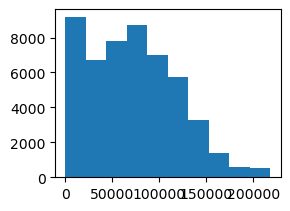

In [87]:
plt.subplot(2,2,2)
plt.hist(new_wage_data)

{'whiskers': [<matplotlib.lines.Line2D at 0x1c0ed59d090>,
 'caps': [<matplotlib.lines.Line2D at 0x1c0ed59d310>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c0ed59cf50>],
 'medians': [<matplotlib.lines.Line2D at 0x1c0ed59d590>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c0ed59d6d0>],
 'means': []}

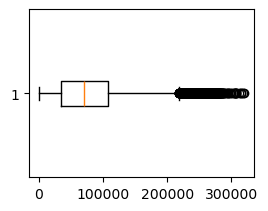

In [88]:
plt.subplot(2,2,3)
plt.boxplot(wage_data,vert=False)

{'whiskers': [<matplotlib.lines.Line2D at 0x1c0ed603250>,
 'caps': [<matplotlib.lines.Line2D at 0x1c0ed6034d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c0ed603110>],
 'medians': [<matplotlib.lines.Line2D at 0x1c0ed603750>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c0ed603890>],
 'means': []}

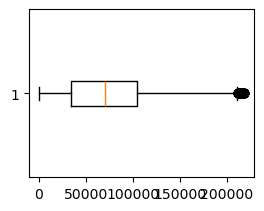

In [89]:
plt.subplot(2,2,3)
plt.boxplot(new_wage_data,vert=False)

**winsorization**

- whatever outlier less than lb fill with lb

- whatever outlier greater than up fill with up

- in numpy we have method clip

In [90]:
wage_data=visa_df['prevailing_wage']

In [91]:
q1=np.percentile(wage_data,25)
q1

np.float64(34015.479999999996)

In [92]:
q2=np.percentile(wage_data,50)
q2

np.float64(70308.20999999999)

In [93]:
q3=np.percentile(wage_data,75)
q3

np.float64(107735.51250000001)

In [94]:
iqr=q3-q1

In [95]:
lb=1-(1.5*iqr)

In [96]:
ub=1+(1.5*iqr)

In [97]:
con1 = wage_data <lb
con2= wage_data >ub

In [98]:
wage_data_clip=np.clip(wage_data,lb,up)

{'whiskers': [<matplotlib.lines.Line2D at 0x1c0ed825090>,
 'caps': [<matplotlib.lines.Line2D at 0x1c0ed825310>,
 'boxes': [<matplotlib.lines.Line2D at 0x1c0ed824f50>],
 'medians': [<matplotlib.lines.Line2D at 0x1c0ed825590>],
 'fliers': [<matplotlib.lines.Line2D at 0x1c0ed8256d0>],
 'means': []}

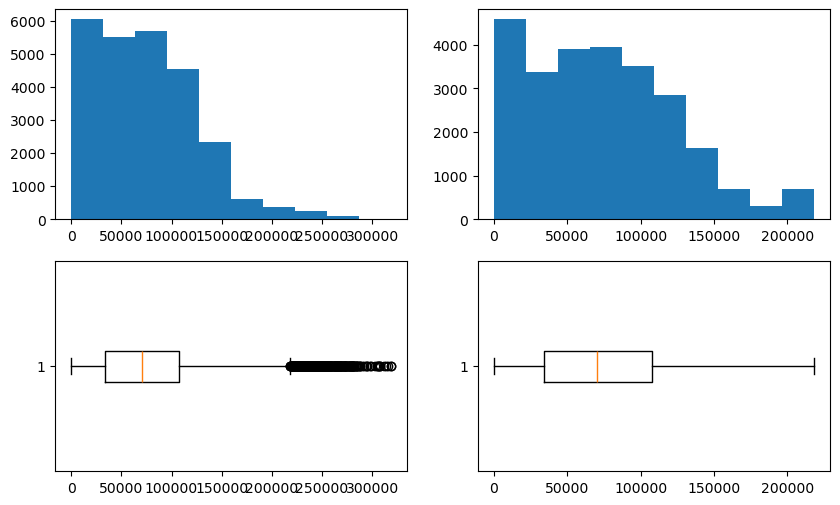

In [99]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt.hist(wage_data)
plt.subplot(2,2,2)
plt.hist(wage_data_clip)
plt.subplot(2,2,3)
plt.boxplot(wage_data,vert=False)
plt.subplot(2,2,4)
plt.boxplot(wage_data_clip,vert=False)
